# Batch MAEST Embeddings + 2D Plot

This notebook computes and saves a MAEST embedding for every `.mp3` in `music/`,
stores outputs in `data/maest_embeddings/`, and generates a labeled 2D PCA plot.


In [ ]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "music").exists() and (PROJECT_ROOT.parent / "music").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from djprojectexploration.maest_embedding_extractor import (
    DEFAULT_MODEL_FILENAME,
    DEFAULT_OUTPUT_NODE,
    extract_embedding,
)

print(f"Project root: {PROJECT_ROOT}")


In [14]:
MUSIC_DIR = PROJECT_ROOT / "music" / "aries-mix"
DATA_DIR = PROJECT_ROOT / "data" / "maest_embeddings"
MODELS_DIR = PROJECT_ROOT / "models"
MODEL_FILE = MODELS_DIR / DEFAULT_MODEL_FILENAME
OUTPUT_NODE = DEFAULT_OUTPUT_NODE

DATA_DIR.mkdir(parents=True, exist_ok=True)

mp3_files = sorted(MUSIC_DIR.glob("*.mp3"))
if not mp3_files:
    raise FileNotFoundError(f"No .mp3 files found in {MUSIC_DIR}")

if not MODEL_FILE.exists():
    candidates = sorted(MODELS_DIR.glob("discogs-maest*.pb"))
    if not candidates:
        raise FileNotFoundError(
            f"Model file not found: {MODEL_FILE}\n"
            f"No fallback discogs-maest*.pb model found in {MODELS_DIR}"
        )
    MODEL_FILE = candidates[0]

print(f"Found {len(mp3_files)} mp3 files in {MUSIC_DIR}")
print(f"Using MAEST model: {MODEL_FILE}")
print(f"Output node: {OUTPUT_NODE}")


Found 25 mp3 files in /Users/josephdaher/Git Repositories/djprojectexploration/music/aries-mix
Using MAEST model: /Users/josephdaher/Git Repositories/djprojectexploration/models/discogs-maest-30s-pw-519l-2.pb
Output node: PartitionedCall/Identity_7


In [ ]:
records = []

for audio_file in mp3_files:
    embedding, raw_shape, reduction = extract_embedding(audio_file, MODEL_FILE, OUTPUT_NODE)

    payload = {
        "title": "MAEST Embedding (Essentia)",
        "filename": audio_file.name,
        "audio_file": str(audio_file),
        "embedding_type": "maest",
        "model_name": MODEL_FILE.stem,
        "model_file": str(MODEL_FILE),
        "output_node": OUTPUT_NODE,
        "reduction": reduction,
        "raw_prediction_shape": list(raw_shape),
        "embedding_dimension": int(embedding.shape[0]),
        "embedding": embedding.tolist(),
    }

    per_track_file = DATA_DIR / f"{audio_file.stem}_maest_embedding.json"
    with per_track_file.open("w", encoding="utf-8") as f:
        json.dump(payload, f, indent=4)

    records.append({
        "filename": audio_file.name,
        "embedding": embedding.astype(np.float32),
        "raw_prediction_shape": list(raw_shape),
        "reduction": reduction,
    })

    print(f"Saved {per_track_file.name} (dim={payload['embedding_dimension']})")

print(f"\nSaved {len(records)} per-track JSON files in {DATA_DIR}")


In [ ]:
filenames = [r["filename"] for r in records]
embeddings = np.vstack([r["embedding"] for r in records]).astype(np.float32)

npz_path = DATA_DIR / "maest_embeddings.npz"
np.savez_compressed(
    npz_path,
    filenames=np.array(filenames),
    embeddings=embeddings,
)

manifest = {
    "title": "MAEST Embedding Collection",
    "model_file": str(MODEL_FILE),
    "output_node": OUTPUT_NODE,
    "num_tracks": len(records),
    "embedding_dimension": int(embeddings.shape[1]),
    "tracks": [
        {
            "filename": r["filename"],
            "reduction": r["reduction"],
            "raw_prediction_shape": r["raw_prediction_shape"],
            "per_track_embedding_file": str(DATA_DIR / f"{Path(r['filename']).stem}_maest_embedding.json"),
        }
        for r in records
    ],
}

manifest_path = DATA_DIR / "maest_embeddings_manifest.json"
with manifest_path.open("w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=4)

print(f"Saved aggregate matrix: {npz_path}")
print(f"Saved manifest: {manifest_path}")
print(f"Embedding matrix shape: {embeddings.shape}")


Loaded track order from: /Users/josephdaher/Git Repositories/djprojectexploration/music/aries-mix/aries_mix_tracks.csv
Matched tracks from CSV against embeddings: 25
CSV tracks not embedded: 0
Embedded tracks not in CSV: 0


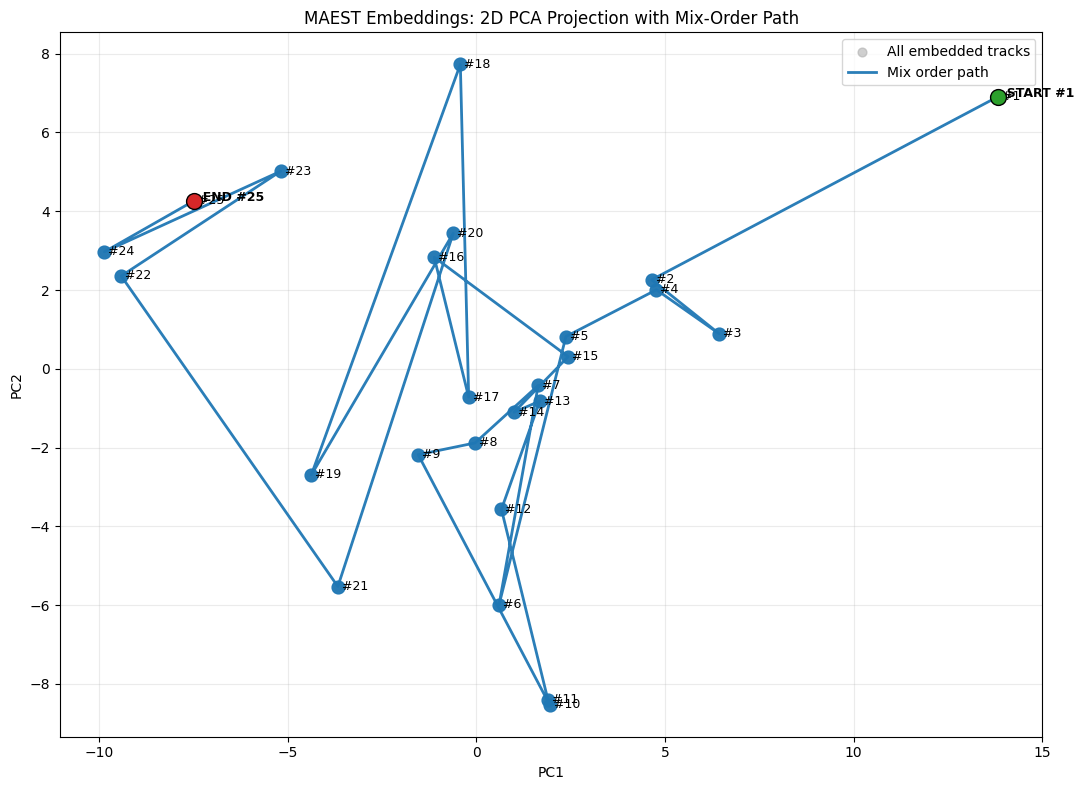

Saved plot: /Users/josephdaher/Git Repositories/djprojectexploration/data/maest_embeddings/maest_embeddings_pca_plot.png


In [10]:
import csv

if embeddings.shape[0] < 2:
    raise ValueError("Need at least 2 tracks to build a 2D projection.")

centered = embeddings - embeddings.mean(axis=0, keepdims=True)
_u, _s, vt = np.linalg.svd(centered, full_matrices=False)
coords = centered @ vt[:2].T
if coords.shape[1] < 2:
    coords = np.pad(coords, ((0, 0), (0, 2 - coords.shape[1])), mode="constant")

fig, ax = plt.subplots(figsize=(11, 8))

# Base layer: all tracks as light points
ax.scatter(coords[:, 0], coords[:, 1], s=40, color="#b0b0b0", alpha=0.6, label="All embedded tracks")

tracklist_csv = PROJECT_ROOT / "music" / "aries-mix" / "aries_mix_tracks.csv"
filename_to_idx = {name.lower(): i for i, name in enumerate(filenames)}
ordered_matches = []
csv_mp3_names = set()

if tracklist_csv.exists():
    with tracklist_csv.open("r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            track_num_raw = (row.get("track_number") or row.get("#") or "").strip()
            mp3_name = (row.get("mp3_name") or "").strip().lower()
            if not track_num_raw or not mp3_name:
                continue

            csv_mp3_names.add(mp3_name)

            try:
                track_num = int(track_num_raw)
            except ValueError:
                continue

            idx = filename_to_idx.get(mp3_name)
            if idx is not None:
                ordered_matches.append((track_num, idx, mp3_name))

ordered_matches.sort(key=lambda x: x[0])

if ordered_matches:
    order_idx = [idx for _track_num, idx, _name in ordered_matches]
    path_coords = coords[order_idx]

    # Draw trajectory in track-number order
    ax.plot(
        path_coords[:, 0],
        path_coords[:, 1],
        color="#1f77b4",
        linewidth=2.0,
        alpha=0.95,
        label="Mix order path",
        zorder=2,
    )
    ax.scatter(path_coords[:, 0], path_coords[:, 1], s=85, color="#1f77b4", alpha=0.95, zorder=3)

    # Label points with track number (#)
    for track_num, idx, _name in ordered_matches:
        ax.text(coords[idx, 0], coords[idx, 1], f" #{track_num}", fontsize=9, va="center")

    # Highlight start/end
    first_num, first_idx, _ = ordered_matches[0]
    last_num, last_idx, _ = ordered_matches[-1]
    ax.scatter(coords[first_idx, 0], coords[first_idx, 1], s=130, color="#2ca02c", edgecolor="black", zorder=4)
    ax.scatter(coords[last_idx, 0], coords[last_idx, 1], s=130, color="#d62728", edgecolor="black", zorder=4)
    ax.text(coords[first_idx, 0], coords[first_idx, 1], f"  START #{first_num}", fontsize=9, weight="bold")
    ax.text(coords[last_idx, 0], coords[last_idx, 1], f"  END #{last_num}", fontsize=9, weight="bold")

    embedding_name_set = set(filename_to_idx.keys())
    unmatched_csv = sorted(csv_mp3_names - embedding_name_set)
    unmatched_embeddings = sorted(embedding_name_set - csv_mp3_names)

    print(f"Loaded track order from: {tracklist_csv}")
    print(f"Matched tracks from CSV against embeddings: {len(ordered_matches)}")
    print(f"CSV tracks not embedded: {len(unmatched_csv)}")
    print(f"Embedded tracks not in CSV: {len(unmatched_embeddings)}")
else:
    # Fallback: label all points by file stem if no CSV matches are found
    for i, name in enumerate(filenames):
        ax.text(coords[i, 0], coords[i, 1], f" {Path(name).stem}", fontsize=9, va="center")
    print("No CSV track-order matches found; fallback labels use filename stems.")

ax.set_title("MAEST Embeddings: 2D PCA Projection with Mix-Order Path")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.25)
ax.legend(loc="best")

plot_path = DATA_DIR / "maest_embeddings_pca_plot.png"
fig.tight_layout()
fig.savefig(plot_path, dpi=220)
plt.show()

print(f"Saved plot: {plot_path}")


### MAEST PaCMAP Projection (Mix-Order Path)

Same visualization as above, but with a 2D PaCMAP projection instead of PCA.


Sample size is smaller than the total number of assigned points, n_neighbors, n_MN, n_FP would be reorganized


Loaded track order from: /Users/josephdaher/Git Repositories/djprojectexploration/music/aries-mix/aries_mix_tracks.csv
Matched tracks from CSV against embeddings: 25
CSV tracks not embedded: 0
Embedded tracks not in CSV: 0


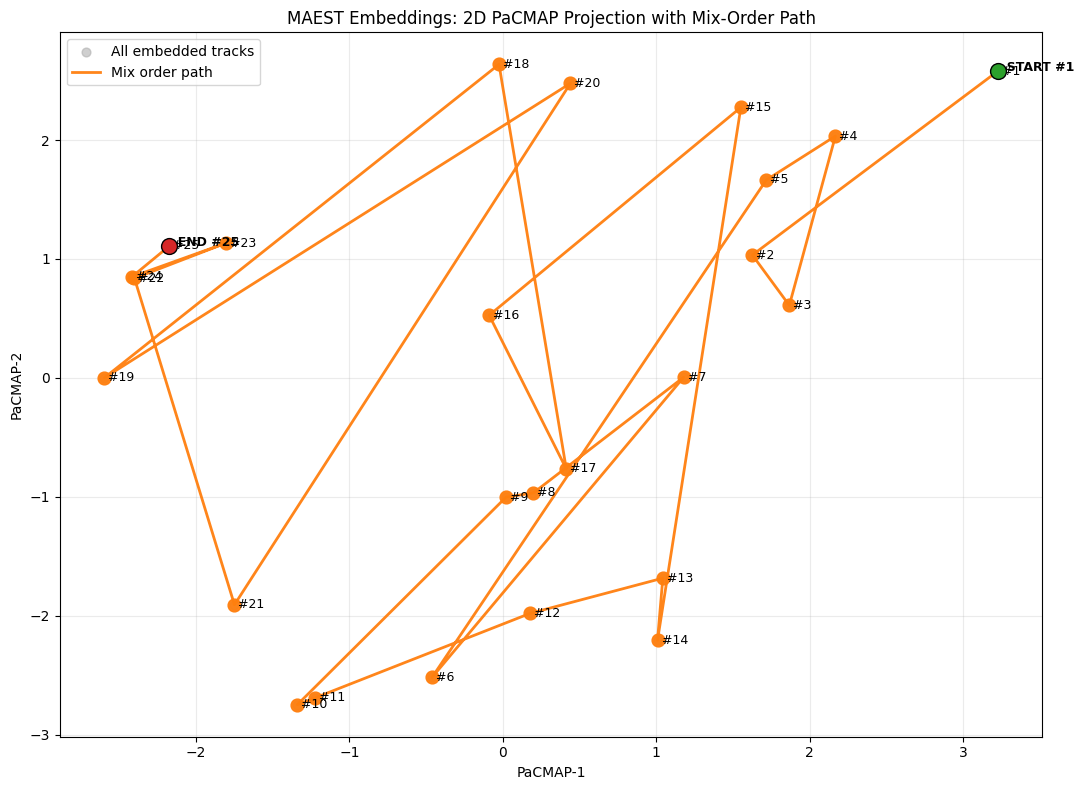

Saved PaCMAP plot: /Users/josephdaher/Git Repositories/djprojectexploration/data/maest_embeddings/maest_embeddings_pacmap_plot.png


In [12]:
import csv

try:
    import pacmap
except ImportError as exc:
    raise ImportError(
        "PaCMAP is not installed in this environment. Install with: pip install pacmap"
    ) from exc

if embeddings.shape[0] < 2:
    raise ValueError("Need at least 2 tracks to build a 2D projection.")

n_neighbors = min(10, max(2, embeddings.shape[0] - 1))
reducer = pacmap.PaCMAP(
    n_components=2,
    n_neighbors=n_neighbors,
    MN_ratio=0.5,
    FP_ratio=2.0,
    random_state=602,
)
coords_pacmap = reducer.fit_transform(embeddings.astype(np.float32))

fig, ax = plt.subplots(figsize=(11, 8))

# Base layer: all tracks as light points
ax.scatter(
    coords_pacmap[:, 0],
    coords_pacmap[:, 1],
    s=40,
    color="#b0b0b0",
    alpha=0.6,
    label="All embedded tracks",
)

tracklist_csv = PROJECT_ROOT / "music" / "aries-mix" / "aries_mix_tracks.csv"
filename_to_idx = {name.lower(): i for i, name in enumerate(filenames)}
ordered_matches = []
csv_mp3_names = set()

if tracklist_csv.exists():
    with tracklist_csv.open("r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            track_num_raw = (row.get("track_number") or row.get("#") or "").strip()
            mp3_name = (row.get("mp3_name") or "").strip().lower()
            if not track_num_raw or not mp3_name:
                continue

            csv_mp3_names.add(mp3_name)

            try:
                track_num = int(track_num_raw)
            except ValueError:
                continue

            idx = filename_to_idx.get(mp3_name)
            if idx is not None:
                ordered_matches.append((track_num, idx, mp3_name))

ordered_matches.sort(key=lambda x: x[0])

if ordered_matches:
    order_idx = [idx for _track_num, idx, _name in ordered_matches]
    path_coords = coords_pacmap[order_idx]

    ax.plot(
        path_coords[:, 0],
        path_coords[:, 1],
        color="#ff7f0e",
        linewidth=2.0,
        alpha=0.95,
        label="Mix order path",
        zorder=2,
    )
    ax.scatter(path_coords[:, 0], path_coords[:, 1], s=85, color="#ff7f0e", alpha=0.95, zorder=3)

    for track_num, idx, _name in ordered_matches:
        ax.text(coords_pacmap[idx, 0], coords_pacmap[idx, 1], f" #{track_num}", fontsize=9, va="center")

    first_num, first_idx, _ = ordered_matches[0]
    last_num, last_idx, _ = ordered_matches[-1]
    ax.scatter(coords_pacmap[first_idx, 0], coords_pacmap[first_idx, 1], s=130, color="#2ca02c", edgecolor="black", zorder=4)
    ax.scatter(coords_pacmap[last_idx, 0], coords_pacmap[last_idx, 1], s=130, color="#d62728", edgecolor="black", zorder=4)
    ax.text(coords_pacmap[first_idx, 0], coords_pacmap[first_idx, 1], f"  START #{first_num}", fontsize=9, weight="bold")
    ax.text(coords_pacmap[last_idx, 0], coords_pacmap[last_idx, 1], f"  END #{last_num}", fontsize=9, weight="bold")

    embedding_name_set = set(filename_to_idx.keys())
    unmatched_csv = sorted(csv_mp3_names - embedding_name_set)
    unmatched_embeddings = sorted(embedding_name_set - csv_mp3_names)

    print(f"Loaded track order from: {tracklist_csv}")
    print(f"Matched tracks from CSV against embeddings: {len(ordered_matches)}")
    print(f"CSV tracks not embedded: {len(unmatched_csv)}")
    print(f"Embedded tracks not in CSV: {len(unmatched_embeddings)}")
else:
    for i, name in enumerate(filenames):
        ax.text(coords_pacmap[i, 0], coords_pacmap[i, 1], f" {Path(name).stem}", fontsize=9, va="center")
    print("No CSV track-order matches found; fallback labels use filename stems.")

ax.set_title("MAEST Embeddings: 2D PaCMAP Projection with Mix-Order Path")
ax.set_xlabel("PaCMAP-1")
ax.set_ylabel("PaCMAP-2")
ax.grid(alpha=0.25)
ax.legend(loc="best")

plot_path_pacmap = DATA_DIR / "maest_embeddings_pacmap_plot.png"
fig.tight_layout()
fig.savefig(plot_path_pacmap, dpi=220)
plt.show()

print(f"Saved PaCMAP plot: {plot_path_pacmap}")


## DEAM Valence/Arousal

This section predicts valence/arousal for each song using the DEAM MusicNN pipeline and saves a labeled visualization.


In [15]:
from djprojectexploration.deam_valence_arousal import (
    predict_deam_valence_arousal_musicnn,
    save_deam_prediction_json,
)

DEAM_DATA_DIR = PROJECT_ROOT / "data" / "deam_valence_arousal"
DEAM_DATA_DIR.mkdir(parents=True, exist_ok=True)

MUSICNN_MODEL_FILE = MODELS_DIR / "msd-musicnn-1.pb"
DEAM_MODEL_FILE = MODELS_DIR / "deam-msd-musicnn-2.pb"

if not MUSICNN_MODEL_FILE.exists():
    candidates = sorted(MODELS_DIR.glob("msd-musicnn*.pb"))
    if not candidates:
        candidates = sorted(MODELS_DIR.glob("*musicnn*.pb"))
    if not candidates:
        raise FileNotFoundError(
            f"MusicNN embedding model not found. Expected {MUSICNN_MODEL_FILE}\n"
            f"Add an msd-musicnn .pb file to {MODELS_DIR}."
        )
    MUSICNN_MODEL_FILE = candidates[0]

if not DEAM_MODEL_FILE.exists():
    candidates = sorted(MODELS_DIR.glob("deam-msd-musicnn*.pb"))
    if not candidates:
        candidates = sorted(MODELS_DIR.glob("deam*musicnn*.pb"))
    if not candidates:
        raise FileNotFoundError(
            f"DEAM regression model not found. Expected {DEAM_MODEL_FILE}\n"
            f"Add a deam-msd-musicnn .pb file to {MODELS_DIR}."
        )
    DEAM_MODEL_FILE = candidates[0]

print(f"Using MusicNN embedding model: {MUSICNN_MODEL_FILE}")
print(f"Using DEAM regression model: {DEAM_MODEL_FILE}")
print(f"DEAM outputs directory: {DEAM_DATA_DIR}")


Using MusicNN embedding model: /Users/josephdaher/Git Repositories/djprojectexploration/models/msd-musicnn-1.pb
Using DEAM regression model: /Users/josephdaher/Git Repositories/djprojectexploration/models/deam-msd-musicnn-2.pb
DEAM outputs directory: /Users/josephdaher/Git Repositories/djprojectexploration/data/deam_valence_arousal


In [16]:
import csv

deam_rows = []

for audio_file in mp3_files:
    prediction = predict_deam_valence_arousal_musicnn(
        audio_file=audio_file,
        embedding_model_file=MUSICNN_MODEL_FILE,
        regression_model_file=DEAM_MODEL_FILE,
    )

    output_json = DEAM_DATA_DIR / f"{audio_file.stem}_deam_valence_arousal.json"
    save_deam_prediction_json(prediction, output_json)

    track = prediction["track_prediction"]
    row = {
        "filename": audio_file.name,
        "valence": float(track["valence"]),
        "arousal": float(track["arousal"]),
        "valence_std": float(track["valence_std"]),
        "arousal_std": float(track["arousal_std"]),
        "num_segments": int(track["num_segments"]),
        "prediction_file": str(output_json),
    }
    deam_rows.append(row)

    print(
        f"{audio_file.name}: valence={row['valence']:.3f}, "
        f"arousal={row['arousal']:.3f}, segments={row['num_segments']}"
    )

summary_json_path = DEAM_DATA_DIR / "deam_track_predictions.json"
with summary_json_path.open("w", encoding="utf-8") as f:
    json.dump({"tracks": deam_rows}, f, indent=4)

summary_csv_path = DEAM_DATA_DIR / "deam_track_predictions.csv"
with summary_csv_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "filename",
            "valence",
            "arousal",
            "valence_std",
            "arousal_std",
            "num_segments",
            "prediction_file",
        ],
    )
    writer.writeheader()
    writer.writerows(deam_rows)

print(f"\nSaved DEAM summary JSON: {summary_json_path}")
print(f"Saved DEAM summary CSV: {summary_csv_path}")


[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/msd-musicnn-1.pb`
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/deam-msd-musicnn-2.pb`


access.mp3: valence=7.224, arousal=5.292, segments=327


[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/msd-musicnn-1.pb`
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/deam-msd-musicnn-2.pb`


apex.mp3: valence=7.463, arousal=5.145, segments=266


[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/msd-musicnn-1.pb`
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/deam-msd-musicnn-2.pb`


...

[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/msd-musicnn-1.pb`
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/deam-msd-musicnn-2.pb`


warrior.mp3: valence=6.349, arousal=6.804, segments=307


[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/msd-musicnn-1.pb`
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/deam-msd-musicnn-2.pb`


water.mp3: valence=5.989, arousal=5.954, segments=171
yesman.mp3: valence=6.677, arousal=5.529, segments=261

Saved DEAM summary JSON: /Users/josephdaher/Git Repositories/djprojectexploration/data/deam_valence_arousal/deam_track_predictions.json
Saved DEAM summary CSV: /Users/josephdaher/Git Repositories/djprojectexploration/data/deam_valence_arousal/deam_track_predictions.csv


[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/msd-musicnn-1.pb`
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/deam-msd-musicnn-2.pb`


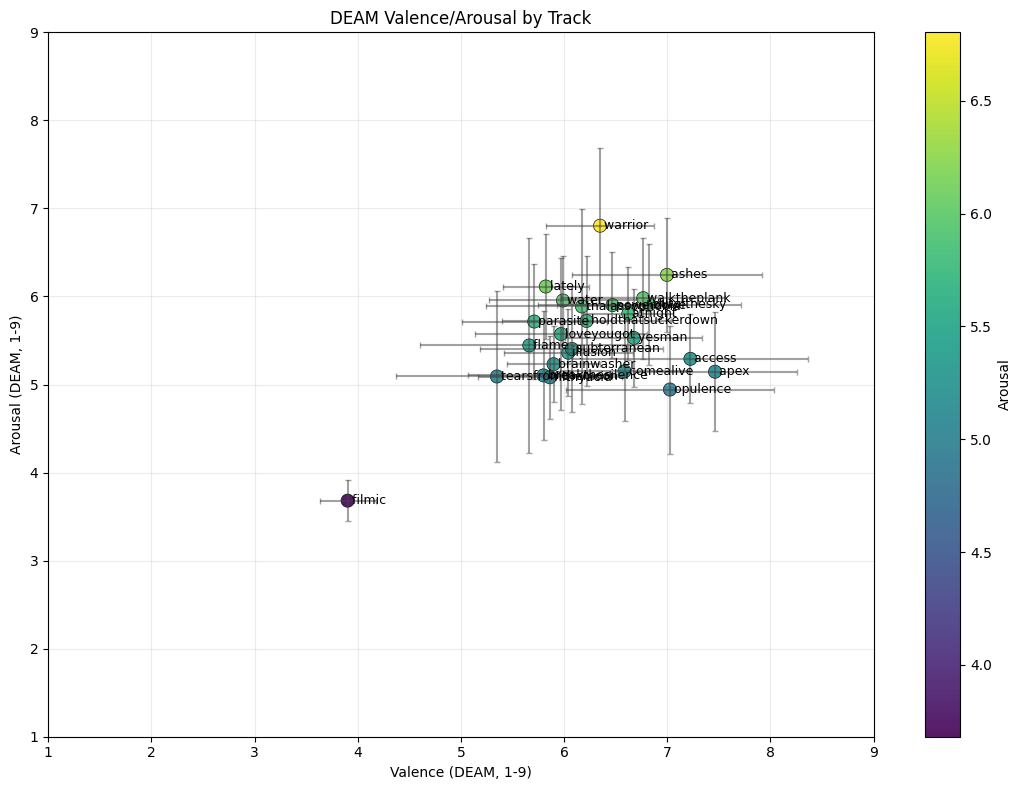

Saved DEAM plot: /Users/josephdaher/Git Repositories/djprojectexploration/data/deam_valence_arousal/deam_valence_arousal_scatter.png


In [17]:
if not deam_rows:
    raise ValueError("No DEAM predictions found. Run the previous cell first.")

names = [Path(row["filename"]).stem for row in deam_rows]
valence = np.array([row["valence"] for row in deam_rows], dtype=np.float32)
arousal = np.array([row["arousal"] for row in deam_rows], dtype=np.float32)
valence_std = np.array([row["valence_std"] for row in deam_rows], dtype=np.float32)
arousal_std = np.array([row["arousal_std"] for row in deam_rows], dtype=np.float32)

fig, ax = plt.subplots(figsize=(11, 8))
scatter = ax.scatter(
    valence,
    arousal,
    c=arousal,
    cmap="viridis",
    s=90,
    alpha=0.9,
    edgecolor="black",
    linewidth=0.5,
)
ax.errorbar(
    valence,
    arousal,
    xerr=valence_std,
    yerr=arousal_std,
    fmt="none",
    ecolor="#444444",
    alpha=0.5,
    capsize=2,
)

for i, name in enumerate(names):
    ax.text(valence[i], arousal[i], f" {name}", fontsize=9, va="center")

ax.set_xlim(1.0, 9.0)
ax.set_ylim(1.0, 9.0)
ax.set_xlabel("Valence (DEAM, 1-9)")
ax.set_ylabel("Arousal (DEAM, 1-9)")
ax.set_title("DEAM Valence/Arousal by Track")
ax.grid(alpha=0.25)

colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label("Arousal")

plot_path = DEAM_DATA_DIR / "deam_valence_arousal_scatter.png"
fig.tight_layout()
fig.savefig(plot_path, dpi=220)
plt.show()

print(f"Saved DEAM plot: {plot_path}")


[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/msd-musicnn-1.pb`
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `/Users/josephdaher/Git Repositories/djprojectexploration/models/deam-msd-musicnn-2.pb`


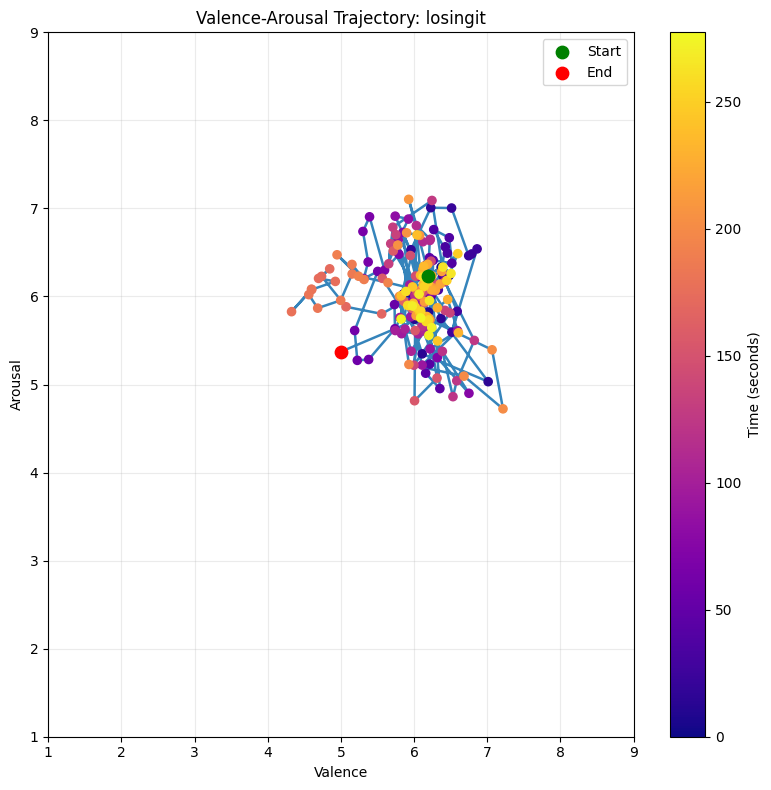

In [9]:
# Valence-Arousal trajectory for one song (2D line over time)
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from essentia.standard import MonoLoader

from djprojectexploration.deam_valence_arousal import predict_deam_valence_arousal_musicnn

# Pick a song
audio_file = PROJECT_ROOT / "music" / "losingit.mp3"

# Reuse model vars if already defined in earlier cells
musicnn_model = MUSICNN_MODEL_FILE if "MUSICNN_MODEL_FILE" in globals() else (PROJECT_ROOT / "models" / "msd-musicnn-1.pb")
deam_model = DEAM_MODEL_FILE if "DEAM_MODEL_FILE" in globals() else (PROJECT_ROOT / "models" / "deam-msd-musicnn-2.pb")

pred = predict_deam_valence_arousal_musicnn(
    audio_file=audio_file,
    embedding_model_file=musicnn_model,
    regression_model_file=deam_model,
)

points = np.array([[p["valence"], p["arousal"]] for p in pred["segment_predictions"]], dtype=np.float32)
n = len(points)

# Approximate segment times across full song duration
audio = MonoLoader(filename=str(audio_file), sampleRate=16000, resampleQuality=4)()
duration_sec = len(audio) / 16000.0
t = np.linspace(0.0, duration_sec, n, endpoint=False)

fig, ax = plt.subplots(figsize=(8, 8))

# Line path through valence-arousal space (ordered by time)
ax.plot(points[:, 0], points[:, 1], color="#1f77b4", linewidth=1.8, alpha=0.9)

# Color points by time
sc = ax.scatter(points[:, 0], points[:, 1], c=t, cmap="plasma", s=35, zorder=3)

# Mark start/end
ax.scatter(points[0, 0], points[0, 1], color="green", s=80, label="Start", zorder=4)
ax.scatter(points[-1, 0], points[-1, 1], color="red", s=80, label="End", zorder=4)

ax.set_xlim(1, 9)
ax.set_ylim(1, 9)
ax.set_xlabel("Valence")
ax.set_ylabel("Arousal")
ax.set_title(f"Valence-Arousal Trajectory: {audio_file.stem}")
ax.grid(alpha=0.25)
ax.legend(loc="best")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Time (seconds)")

plt.tight_layout()
plt.show()


## Mix-Order Embedding Distance Analysis\n
\n
Compute cosine similarity and Euclidean distance between consecutive tracks in mix order, plus full pairwise distance matrices and heatmaps.\n

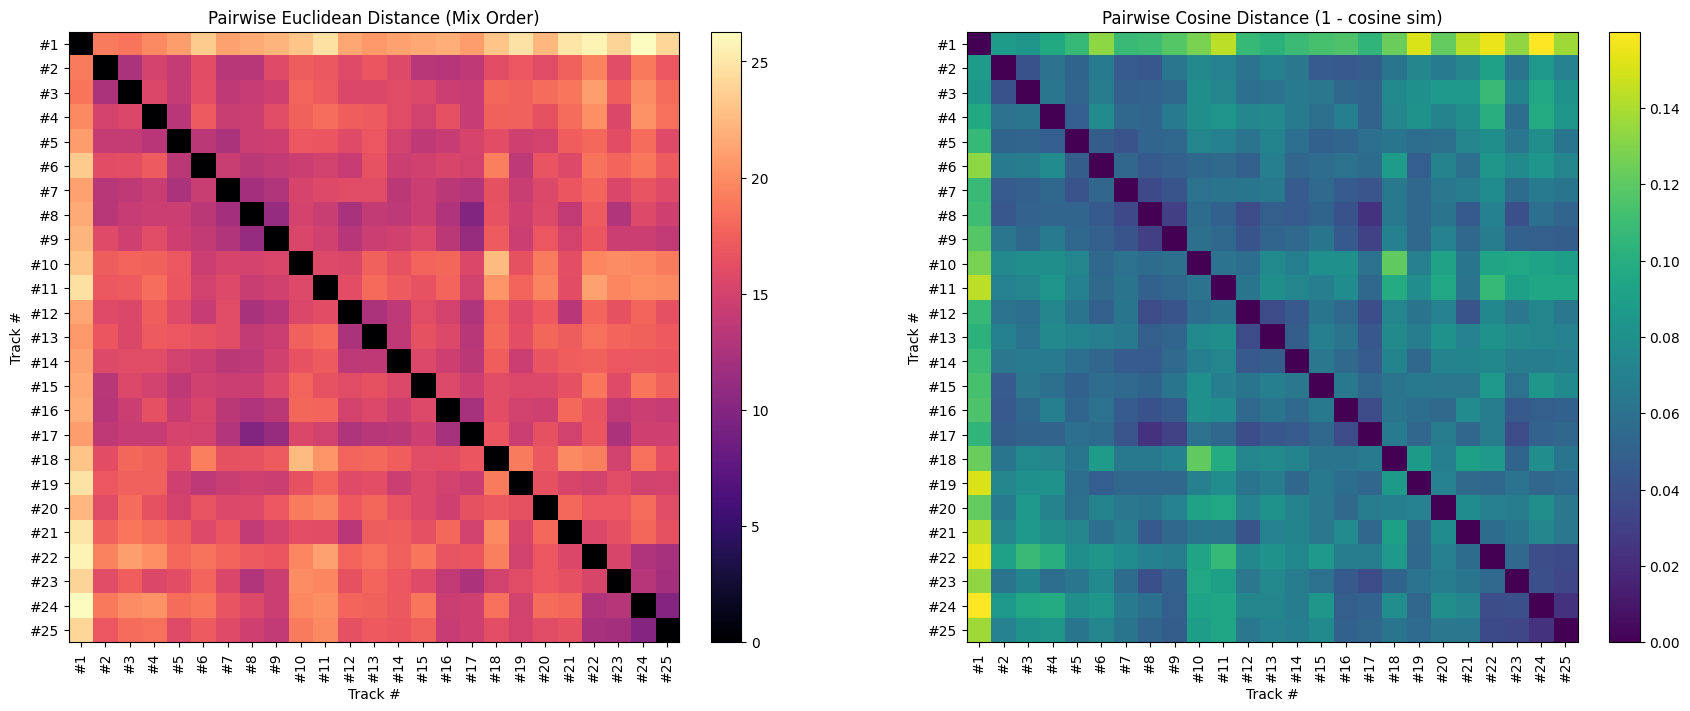

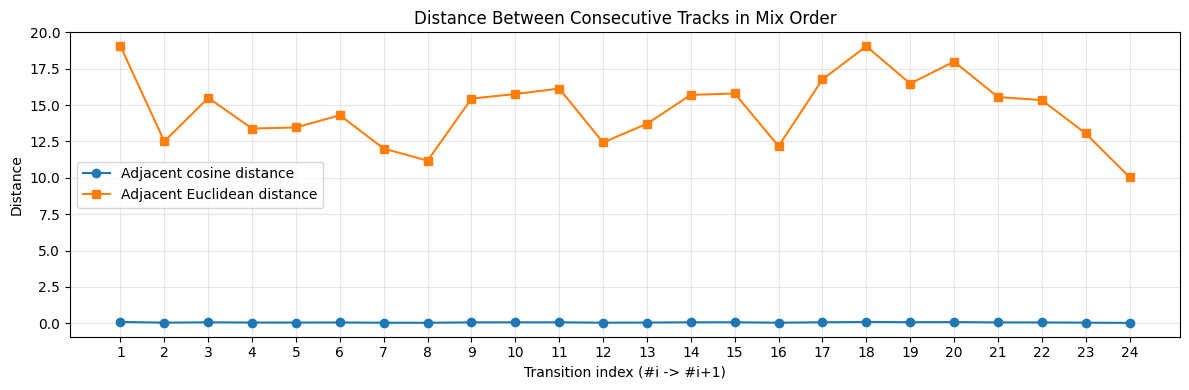

Matched tracks in mix order: 25
Saved transition table: /Users/josephdaher/Git Repositories/djprojectexploration/data/maest_embeddings/mix_similarity/mix_order_transition_distances.csv
Saved pairwise matrices: /Users/josephdaher/Git Repositories/djprojectexploration/data/maest_embeddings/mix_similarity/pairwise_distance_matrices.npz
Saved heatmaps: /Users/josephdaher/Git Repositories/djprojectexploration/data/maest_embeddings/mix_similarity/pairwise_distance_heatmaps.png
Saved adjacent-distance plot: /Users/josephdaher/Git Repositories/djprojectexploration/data/maest_embeddings/mix_similarity/adjacent_transition_distances.png

First 5 transitions:
#1 -> #2: cos_dist=0.0878, euclid=19.0570
#2 -> #3: cos_dist=0.0401, euclid=12.5021
#3 -> #4: cos_dist=0.0630, euclid=15.5044
#4 -> #5: cos_dist=0.0479, euclid=13.3900
#5 -> #6: cos_dist=0.0469, euclid=13.4650


In [13]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

if "embeddings" not in globals() or "filenames" not in globals():
    raise RuntimeError("Run the MAEST embedding cells first so `embeddings` and `filenames` exist.")

tracklist_csv = PROJECT_ROOT / "music" / "aries-mix" / "aries_mix_tracks.csv"
if not tracklist_csv.exists():
    raise FileNotFoundError(f"Tracklist CSV not found: {tracklist_csv}")

filename_to_idx = {name.lower(): i for i, name in enumerate(filenames)}
ordered_tracks = []

with tracklist_csv.open("r", encoding="utf-8", newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        track_num_raw = (row.get("track_number") or row.get("#") or "").strip()
        mp3_name = (row.get("mp3_name") or "").strip().lower()
        title = (row.get("title") or "").strip()
        if not track_num_raw or not mp3_name:
            continue
        try:
            track_number = int(track_num_raw)
        except ValueError:
            continue
        idx = filename_to_idx.get(mp3_name)
        if idx is None:
            continue
        ordered_tracks.append(
            {
                "track_number": track_number,
                "title": title,
                "mp3_name": mp3_name,
                "embedding_index": idx,
            }
        )

ordered_tracks.sort(key=lambda x: x["track_number"])
if len(ordered_tracks) < 2:
    raise ValueError("Need at least 2 matched tracks in CSV to compute mix-order distances.")

order_idx = [t["embedding_index"] for t in ordered_tracks]
ordered_embeddings = embeddings[order_idx].astype(np.float32)
n_tracks = ordered_embeddings.shape[0]

# Pairwise cosine similarity/distance
norms = np.linalg.norm(ordered_embeddings, axis=1, keepdims=True)
norms = np.where(norms == 0, 1.0, norms)
emb_norm = ordered_embeddings / norms
cosine_similarity_matrix = emb_norm @ emb_norm.T
cosine_similarity_matrix = np.clip(cosine_similarity_matrix, -1.0, 1.0)
cosine_distance_matrix = 1.0 - cosine_similarity_matrix
cosine_distance_matrix = np.clip(cosine_distance_matrix, 0.0, 2.0)

# Pairwise Euclidean distance
diff = ordered_embeddings[:, None, :] - ordered_embeddings[None, :, :]
euclidean_distance_matrix = np.linalg.norm(diff, axis=2)

# Consecutive transitions in mix order
transitions = []
for i in range(n_tracks - 1):
    a = ordered_tracks[i]
    b = ordered_tracks[i + 1]
    transitions.append(
        {
            "from_track_number": a["track_number"],
            "from_title": a["title"],
            "from_mp3": a["mp3_name"],
            "to_track_number": b["track_number"],
            "to_title": b["title"],
            "to_mp3": b["mp3_name"],
            "cosine_similarity": float(cosine_similarity_matrix[i, i + 1]),
            "cosine_distance": float(cosine_distance_matrix[i, i + 1]),
            "euclidean_distance": float(euclidean_distance_matrix[i, i + 1]),
        }
    )

# Save outputs
SIM_DIR = DATA_DIR / "mix_similarity"
SIM_DIR.mkdir(parents=True, exist_ok=True)

transitions_csv = SIM_DIR / "mix_order_transition_distances.csv"
with transitions_csv.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "from_track_number",
            "from_title",
            "from_mp3",
            "to_track_number",
            "to_title",
            "to_mp3",
            "cosine_similarity",
            "cosine_distance",
            "euclidean_distance",
        ],
    )
    writer.writeheader()
    writer.writerows(transitions)

labels = [f"#{t['track_number']}" for t in ordered_tracks]
np.savez_compressed(
    SIM_DIR / "pairwise_distance_matrices.npz",
    labels=np.array(labels),
    cosine_similarity=cosine_similarity_matrix,
    cosine_distance=cosine_distance_matrix,
    euclidean_distance=euclidean_distance_matrix,
)

# Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)

im0 = axes[0].imshow(euclidean_distance_matrix, cmap="magma")
axes[0].set_title("Pairwise Euclidean Distance (Mix Order)")
axes[0].set_xticks(np.arange(n_tracks))
axes[0].set_yticks(np.arange(n_tracks))
axes[0].set_xticklabels(labels, rotation=90)
axes[0].set_yticklabels(labels)
axes[0].set_xlabel("Track #")
axes[0].set_ylabel("Track #")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(cosine_distance_matrix, cmap="viridis")
axes[1].set_title("Pairwise Cosine Distance (1 - cosine sim)")
axes[1].set_xticks(np.arange(n_tracks))
axes[1].set_yticks(np.arange(n_tracks))
axes[1].set_xticklabels(labels, rotation=90)
axes[1].set_yticklabels(labels)
axes[1].set_xlabel("Track #")
axes[1].set_ylabel("Track #")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

heatmap_path = SIM_DIR / "pairwise_distance_heatmaps.png"
fig.savefig(heatmap_path, dpi=220)
plt.show()

# Adjacent transition trend plot
x = np.arange(1, n_tracks)
adj_cos = np.array([row["cosine_distance"] for row in transitions], dtype=np.float32)
adj_euc = np.array([row["euclidean_distance"] for row in transitions], dtype=np.float32)

fig2, ax2 = plt.subplots(figsize=(12, 4))
ax2.plot(x, adj_cos, marker="o", label="Adjacent cosine distance")
ax2.plot(x, adj_euc, marker="s", label="Adjacent Euclidean distance")
ax2.set_title("Distance Between Consecutive Tracks in Mix Order")
ax2.set_xlabel("Transition index (#i -> #i+1)")
ax2.set_ylabel("Distance")
ax2.set_xticks(x)
ax2.grid(alpha=0.3)
ax2.legend(loc="best")
transition_plot_path = SIM_DIR / "adjacent_transition_distances.png"
fig2.tight_layout()
fig2.savefig(transition_plot_path, dpi=220)
plt.show()

print(f"Matched tracks in mix order: {n_tracks}")
print(f"Saved transition table: {transitions_csv}")
print(f"Saved pairwise matrices: {SIM_DIR / 'pairwise_distance_matrices.npz'}")
print(f"Saved heatmaps: {heatmap_path}")
print(f"Saved adjacent-distance plot: {transition_plot_path}")
print()
print("First 5 transitions:")
for row in transitions[:5]:
    print(
        f"#{row['from_track_number']} -> #{row['to_track_number']}: "
        f"cos_dist={row['cosine_distance']:.4f}, "
        f"euclid={row['euclidean_distance']:.4f}"
    )
